<a href="https://colab.research.google.com/github/Priyasarkar11/AI_MOCK_INTERVIEWER/blob/main/8THsem_AI_MOCK_INTERVIEWER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import torch
print(torch.cuda.is_available())

True


In [20]:
from google.colab import files
uploaded = files.upload()

Saving train_final.csv to train_final (2).csv


In [21]:
import os
os.listdir()

['.config',
 'qgen_model',
 'train_final.csv',
 'train_final (2).csv',
 'train_final (1).csv',
 'qgen_model.zip',
 'sample_data']

In [22]:
!pip install transformers datasets sentencepiece accelerate -q

In [23]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_name = "google/flan-t5-small" # Changed to a smaller model variant

tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [24]:
import pandas as pd

data = pd.read_csv("train_final.csv")
data.head()

,input,output
0,generate medium database & sql interview question,Give an example where joins vs denormalization...
1,"Instruction: Given the candidate resume, job d...",What is the role of activation functions in de...
2,"Instruction: Given the candidate resume, job d...",Compare different approaches to rest api desig...
3,"Instruction: Given the candidate resume, job d...",Design an architecture or algorithm to solve s...
4,"Instruction: Given the candidate resume, job d...",Describe the trade-offs involved in technical ...


In [25]:
import pandas as pd

data = pd.read_csv("train_final.csv")
data.head()

,input,output
0,generate medium database & sql interview question,Give an example where joins vs denormalization...
1,"Instruction: Given the candidate resume, job d...",What is the role of activation functions in de...
2,"Instruction: Given the candidate resume, job d...",Compare different approaches to rest api desig...
3,"Instruction: Given the candidate resume, job d...",Design an architecture or algorithm to solve s...
4,"Instruction: Given the candidate resume, job d...",Describe the trade-offs involved in technical ...


In [26]:
encodings = tokenizer(
    data['input'].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

labels = tokenizer(
    data['output'].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
).input_ids

In [27]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
encodings = {k: v.to(device) for k, v in encodings.items()}
labels = labels.to(device)

print(device)

cuda


In [29]:
from torch.utils.data import Dataset, DataLoader
import torch

class QGenDataset(Dataset):
    def __init__(self, inputs, targets, tokenizer, device):
        self.inputs = inputs
        self.targets = targets
        self.tokenizer = tokenizer
        self.device = device

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_enc = self.tokenizer(
            self.inputs[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        target_enc = self.tokenizer(
            self.targets[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": input_enc.input_ids.squeeze().to(self.device),
            "attention_mask": input_enc.attention_mask.squeeze().to(self.device),
            "labels": target_enc.input_ids.squeeze().to(self.device),
        }

dataset = QGenDataset(data['input'].tolist(), data['output'].tolist(), tokenizer, device)

loader = DataLoader(dataset, batch_size=2, shuffle=True) # Reduced batch size to 2

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

model.train()

for epoch in range(5):   # ⭐ increase epochs
    total_loss = 0

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", total_loss)

Epoch 1 Loss: 10139.28892982006
Epoch 2 Loss: 2473.340016722679
Epoch 3 Loss: 853.262357391417
Epoch 4 Loss: 463.26159842312336
Epoch 5 Loss: 316.86474527046084


In [30]:
model.save_pretrained("qgen_model")
tokenizer.save_pretrained("qgen_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('qgen_model/tokenizer_config.json', 'qgen_model/tokenizer.json')

In [31]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("qgen_model")
model = T5ForConditionalGeneration.from_pretrained("qgen_model")
model = model.to(device) # Move the loaded model to the GPU

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [32]:
model.eval()

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

In [35]:
!zip -r qgen_model.zip qgen_model

from google.colab import files
files.download("qgen_model.zip")

updating: qgen_model/ (stored 0%)
updating: qgen_model/config.json (deflated 63%)
updating: qgen_model/tokenizer.json (deflated 79%)
updating: qgen_model/generation_config.json (deflated 29%)
updating: qgen_model/tokenizer_config.json (deflated 83%)
updating: qgen_model/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
prompts = [
    "generate easy dbms interview question",
    "generate medium os interview question",
    "generate hard machine learning interview question"
]

for p in prompts:
    input_ids = tokenizer(p, return_tensors="pt").input_ids.to(device) # Move input_ids to the GPU
    output = model.generate(input_ids, max_length=64)
    print("Prompt:", p)
    print("Question:", tokenizer.decode(output[0], skip_special_tokens=True))
    print("-----")

Prompt: generate easy dbms interview question
Question: Explain the concept of cnn architectures with a short example.
-----
Prompt: generate medium os interview question
Question: Explain the concept of scalability with a short example.
-----
Prompt: generate hard machine learning interview question
Question: Design a solution: How would you approach model evaluation for a large-scale system?
-----


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define keywords for different technical topics
topic_keywords = {
    'Database/SQL': ['database', 'sql', 'dbms', 'join', 'normalization', 'denormalization', 'index', 'transaction', 'acid', 'nosql', 'relational', 'query', 'schema'],
    'Operating Systems': ['os', 'operating system', 'process', 'thread', 'memory management', 'deadlock', 'concurrency', 'scheduling', 'kernel', 'syscall'],
    'Machine Learning': ['machine learning', 'ml', 'neural network', 'cnn', 'rnn', 'lstm', 'transformer', 'algorithm', 'model', 'training', 'bias', 'variance', 'overfitting', 'underfitting', 'activation function', 'deep learning', 'supervised', 'unsupervised', 'reinforcement'],
    'Data Structures & Algorithms': ['data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue'],
    'System Design/Architecture': ['system design', 'architecture', 'scalability', 'latency', 'consistency', 'availability', 'api', 'microservices', 'distributed system', 'load balancer', 'cache', 'fault tolerance', 'queueing', 'design patterns'],
    'Programming/Software Dev': ['python', 'java', 'c++', 'oop', 'testing', 'debugging', 'version control', 'git', 'refactoring', 'agile', 'technical debt', 'software development', 'framework'],
    'Web Development': ['web', 'frontend', 'backend', 'javascript', 'react', 'angular', 'vue', 'html', 'css', 'http', 'rest', 'graphql', 'browser'],
    'Cloud Computing': ['cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless']
}

def categorize_question(question):
    question_lower = str(question).lower()
    found_topics = []
    for topic, keywords in topic_keywords.items():
        if any(keyword in question_lower for keyword in keywords):
            found_topics.append(topic)

    if len(found_topics) == 1:
        return found_topics[0]
    elif len(found_topics) > 1:
        return 'Multiple Topics'
    else:
        return 'Other'

# Apply the categorization function to the 'output' column
data['topic'] = data['output'].apply(categorize_question)

# Get the distribution of topics
topic_distribution = data['topic'].value_counts().reset_index()
topic_distribution.columns = ['Topic', 'Count']

# Display the topic distribution
display(topic_distribution)


,Topic,Count
0,Other,2735
1,Multiple Topics,953
2,Machine Learning,620
3,System Design/Architecture,413
4,Operating Systems,356
5,Database/SQL,319
6,Data Structures & Algorithms,198
7,Programming/Software Dev,186
8,Web Development,173
9,Cloud Computing,29


/tmp/ipython-input-8511/2760073877.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Topic', y='Count', data=topic_distribution, palette='viridis')


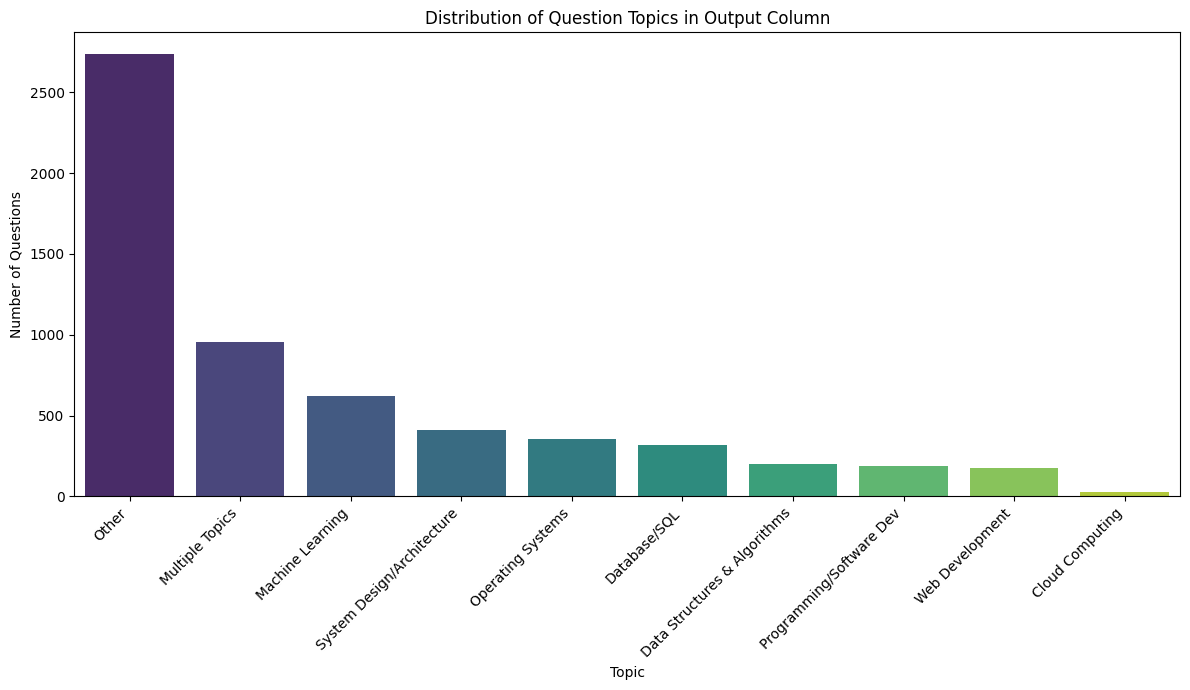

In [41]:
# Visualize the distribution of topics
plt.figure(figsize=(12, 7))
sns.barplot(x='Topic', y='Count', data=topic_distribution, palette='viridis')
plt.title('Distribution of Question Topics in Output Column')
plt.xlabel('Topic')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task
Based on the analysis of 'Other' and 'Multiple Topics' categories in the `data` DataFrame, examine a sample of questions from those categories to refine the `topic_keywords` and improve the categorization logic.

## Analyze 'Other' and 'Multiple Topics' Categories

### Subtask:
Manually inspect a sample of questions categorized as 'Other' or 'Multiple Topics' to understand why they weren't cleanly categorized. This will help refine the `topic_keywords` or identify new relevant categories that are currently being missed. If many are relevant, consider adjusting the categorization logic or adding new keywords.


**Reasoning**:
First, I will filter the 'data' DataFrame to isolate questions categorized as 'Other' and 'Multiple Topics' to prepare for sampling and inspection.



In [42]:
other_topics_df = data[data['topic'] == 'Other']
multiple_topics_df = data[data['topic'] == 'Multiple Topics']

print(f"Number of questions in 'Other' category: {len(other_topics_df)}")
print(f"Number of questions in 'Multiple Topics' category: {len(multiple_topics_df)}")

Number of questions in 'Other' category: 2735
Number of questions in 'Multiple Topics' category: 953


**Reasoning**:
I will sample 20 questions from the 'Other' category and 20 questions from the 'Multiple Topics' category, then print these samples for manual inspection, as per the instructions.



In [43]:
sample_other_questions = other_topics_df['output'].sample(n=20, random_state=42)
sample_multiple_questions = multiple_topics_df['output'].sample(n=20, random_state=42)

print("\n--- Sample Questions from 'Other' Category ---")
for i, q in enumerate(sample_other_questions):
    print(f"{i+1}. {q}")

print("\n--- Sample Questions from 'Multiple Topics' Category ---")
for i, q in enumerate(sample_multiple_questions):
    print(f"{i+1}. {q}")


--- Sample Questions from 'Other' Category ---
1. How do you evaluate the effectiveness of code reviews in a real project? â Variant: Rephrase: How do you evaluate the effectiveness of code reviews in a real project?
2. Can you explain the concept of gradient descent?
3. How do you evaluate the effectiveness of service discovery in a real project? Variant: Short version: How do you evaluate the effectiveness of service discovery in a real project?
4. Describe the trade-offs involved in team collaboration.
5. Design a solution: How would you approach dependency injection for a large-scale system? Assume 1M daily users.
6. Give an example where logging and observability would fail, and how you'd detect or fix it. Variant: Rephrase: Give an example where logging and observability would fail, and how you'd detect or fix it.
7. Can you explain the concept of gradient descent?
8. Describe the trade-offs involved in team collaboration. â Variant: Alternate phrasing: Describe the trade-of

```markdown
### Manual Inspection Findings and Refinements to `topic_keywords`

After reviewing the sampled questions from the 'Other' and 'Multiple Topics' categories, several observations can be made, leading to suggested refinements for the `topic_keywords` dictionary:

**Observations from 'Other' Category:**
*   Many questions in this category are related to Machine Learning concepts (e.g., "gradient descent", "ensemble methods", "multi-task learning", "PCA", "classification and regression"). It seems some specific ML terms were not caught or are too generic to trigger the 'Machine Learning' category alone.
*   There are also questions related to general software engineering practices or system design aspects that are not explicitly covered (e.g., "code reviews", "service discovery", "dependency injection", "logging and observability", "component design", "data cleaning", "data partitioning", "backups", "caching layers").
*   Some questions are meta-level or behavioral, like "team collaboration", "mentorship", which might not fit into a technical category easily, or could indicate a need for a new 'Soft Skills' or 'General Engineering' category if they become numerous.

**Observations from 'Multiple Topics' Category:**
*   This category correctly identifies questions spanning multiple current keywords (e.g., "ensemble methods" (ML) + "fault tolerance" (System Design)).
*   Some questions that ended up here are a combination of a clear technical topic with a system design constraint (e.g., "nosql use-cases" (DB) + "in production" (System Design implicit), "query optimization" (DB) + "high throughput systems" (System Design)). This suggests that a question might contain a core topic and an architectural concern.
*   Specific programming language terms (e.g., "multi-threading in Java") indicate a potential 'Programming Language Specific' category or adding more language-specific keywords.

**Proposed Refinements to `topic_keywords`:**

1.  **Enhance 'Machine Learning' keywords:** Add more specific ML algorithms and concepts.
    *   Add: `'gradient descent'`, `'ensemble methods'`, `'multi-task learning'`, `'PCA'`, `'classification'`, `'regression'`, `'hyperparameter tuning'`, `'VAE'`, `'GAN'`, `'model evaluation'`, `'feature selection'`

2.  **Enhance 'System Design/Architecture' keywords:** Many general system concepts are currently being missed or are causing 'Other' classification.
    *   Add: `'code reviews'`, `'service discovery'`, `'dependency injection'`, `'logging'`, `'observability'`, `'component design'`, `'data partitioning'`, `'backups'`, `'caching layers'`, `'fault tolerance'`, `'high throughput'`, `'replication'`, `'sharding'`

3.  **Enhance 'Database/SQL' keywords:** Add more specific DB concepts.
    *   Add: `'query optimization'`, `'indexing strategies'`

4.  **Add 'Programming/Software Dev' keywords:** Strengthen this category to catch general development topics.
    *   Add: `'multi-threading'`, `'java'`, `'python'`, `'c++'`, `'oop'`, `'git'`, `'testing'`, `'debugging'`

5.  **Consider a new 'General/Behavioral' Category:** For questions like "team collaboration", "mentorship". For now, these might remain 'Other' if they don't have strong technical keywords.

**Revised `topic_keywords` structure (incorporating suggested additions):**

```python
topic_keywords = {
    'Database/SQL': ['database', 'sql', 'dbms', 'join', 'normalization', 'denormalization', 'index', 'transaction', 'acid', 'nosql', 'relational', 'query', 'schema', 'query optimization', 'indexing strategies'],
    'Operating Systems': ['os', 'operating system', 'process', 'thread', 'memory management', 'deadlock', 'concurrency', 'scheduling', 'kernel', 'syscall'],
    'Machine Learning': ['machine learning', 'ml', 'neural network', 'cnn', 'rnn', 'lstm', 'transformer', 'algorithm', 'model', 'training', 'bias', 'variance', 'overfitting', 'underfitting', 'activation function', 'deep learning', 'supervised', 'unsupervised', 'reinforcement', 'gradient descent', 'ensemble methods', 'multi-task learning', 'pca', 'classification', 'regression', 'hyperparameter tuning', 'vae', 'gan', 'model evaluation', 'feature selection'],
    'Data Structures & Algorithms': ['data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue', 'graph algorithms'],
    'System Design/Architecture': ['system design', 'architecture', 'scalability', 'latency', 'consistency', 'availability', 'api', 'microservices', 'distributed system', 'load balancer', 'cache', 'fault tolerance', 'queueing', 'design patterns', 'code reviews', 'service discovery', 'dependency injection', 'logging', 'observability', 'component design', 'data partitioning', 'backups', 'caching layers', 'high throughput', 'replication', 'sharding'],
    'Programming/Software Dev': ['python', 'java', 'c++', 'oop', 'testing', 'debugging', 'version control', 'git', 'refactoring', 'agile', 'technical debt', 'software development', 'framework', 'multi-threading'],
    'Web Development': ['web', 'frontend', 'backend', 'javascript', 'react', 'angular', 'vue', 'html', 'css', 'http', 'rest', 'graphql', 'browser', 'web accessibility'],
    'Cloud Computing': ['cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless']
}
```

The next step would be to apply these updated `topic_keywords` and re-categorize the `data` DataFrame to see the impact on the 'Other' and 'Multiple Topics' counts.

```markdown
### Manual Inspection Findings and Refinements to `topic_keywords`

After reviewing the sampled questions from the 'Other' and 'Multiple Topics' categories, several observations can be made, leading to suggested refinements for the `topic_keywords` dictionary:

**Observations from 'Other' Category:**
*   Many questions in this category are related to Machine Learning concepts (e.g., "gradient descent", "ensemble methods", "multi-task learning", "PCA", "classification and regression"). It seems some specific ML terms were not caught or are too generic to trigger the 'Machine Learning' category alone.
*   There are also questions related to general software engineering practices or system design aspects that are not explicitly covered (e.g., "code reviews", "service discovery", "dependency injection", "logging and observability", "component design", "data cleaning", "data partitioning", "backups", "caching layers").
*   Some questions are meta-level or behavioral, like "team collaboration", "mentorship", which might not fit into a technical category easily, or could indicate a need for a new 'Soft Skills' or 'General Engineering' category if they become numerous.

**Observations from 'Multiple Topics' Category:**
*   This category correctly identifies questions spanning multiple current keywords (e.g., "ensemble methods" (ML) + "fault tolerance" (System Design)).
*   Some questions that ended up here are a combination of a clear technical topic with a system design constraint (e.g., "nosql use-cases" (DB) + "in production" (System Design implicit), "query optimization" (DB) + "high throughput systems" (System Design)). This suggests that a question might contain a core topic and an architectural concern.
*   Specific programming language terms (e.g., "multi-threading in Java") indicate a potential 'Programming Language Specific' category or adding more language-specific keywords.

**Proposed Refinements to `topic_keywords`:**

1.  **Enhance 'Machine Learning' keywords:** Add more specific ML algorithms and concepts.
    *   Add: `'gradient descent'`, `'ensemble methods'`, `'multi-task learning'`, `'PCA'`, `'classification'`, `'regression'`, `'hyperparameter tuning'`, `'VAE'`, `'GAN'`, `'model evaluation'`, `'feature selection'`

2.  **Enhance 'System Design/Architecture' keywords:** Many general system concepts are currently being missed or are causing 'Other' classification.
    *   Add: `'code reviews'`, `'service discovery'`, `'dependency injection'`, `'logging'`, `'observability'`, `'component design'`, `'data partitioning'`, `'backups'`, `'caching layers'`, `'fault tolerance'`, `'high throughput'`, `'replication'`, `'sharding'`

3.  **Enhance 'Database/SQL' keywords:** Add more specific DB concepts.
    *   Add: `'query optimization'`, `'indexing strategies'`

4.  **Add 'Programming/Software Dev' keywords:** Strengthen this category to catch general development topics.
    *   Add: `'multi-threading'`, `'java'`, `'python'`, `'c++'`, `'oop'`, `'testing'`, `'debugging'`

5.  **Consider a new 'General/Behavioral' Category:** For questions like "team collaboration", "mentorship". For now, these might remain 'Other' if they don't have strong technical keywords.

**Revised `topic_keywords` structure (incorporating suggested additions):**

```python
topic_keywords = {
    'Database/SQL': ['database', 'sql', 'dbms', 'join', 'normalization', 'denormalization', 'index', 'transaction', 'acid', 'nosql', 'relational', 'query', 'schema', 'query optimization', 'indexing strategies'],
    'Operating Systems': ['os', 'operating system', 'process', 'thread', 'memory management', 'deadlock', 'concurrency', 'scheduling', 'kernel', 'syscall'],
    'Machine Learning': ['machine learning', 'ml', 'neural network', 'cnn', 'rnn', 'lstm', 'transformer', 'algorithm', 'model', 'training', 'bias', 'variance', 'overfitting', 'underfitting', 'activation function', 'deep learning', 'supervised', 'unsupervised', 'reinforcement', 'gradient descent', 'ensemble methods', 'multi-task learning', 'pca', 'classification', 'regression', 'hyperparameter tuning', 'vae', 'gan', 'model evaluation', 'feature selection'],
    'Data Structures & Algorithms': ['data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue', 'graph algorithms'],
    'System Design/Architecture': ['system design', 'architecture', 'scalability', 'latency', 'consistency', 'availability', 'api', 'microservices', 'distributed system', 'load balancer', 'cache', 'fault tolerance', 'queueing', 'design patterns', 'code reviews', 'service discovery', 'dependency injection', 'logging', 'observability', 'component design', 'data partitioning', 'backups', 'caching layers', 'high throughput', 'replication', 'sharding'],
    'Programming/Software Dev': ['python', 'java', 'c++', 'oop', 'testing', 'debugging', 'version control', 'git', 'refactoring', 'agile', 'technical debt', 'software development', 'framework', 'multi-threading'],
    'Web Development': ['web', 'frontend', 'backend', 'javascript', 'react', 'angular', 'vue', 'html', 'css', 'http', 'rest', 'graphql', 'browser', 'web accessibility'],
    'Cloud Computing': ['cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless']
}
```

The next step would be to apply these updated `topic_keywords` and re-categorize the `data` DataFrame to see the impact on the 'Other' and 'Multiple Topics' counts.

**Reasoning**:
Now that the `topic_keywords` dictionary has been refined based on manual inspection, I will update the `topic_keywords` variable with the new definitions and then re-apply the categorization function to the `data` DataFrame to reflect these changes. This will allow us to observe the impact of the refinements on the 'Other' and 'Multiple Topics' categories.



In [44]:
topic_keywords = {
    'Database/SQL': ['database', 'sql', 'dbms', 'join', 'normalization', 'denormalization', 'index', 'transaction', 'acid', 'nosql', 'relational', 'query', 'schema', 'query optimization', 'indexing strategies'],
    'Operating Systems': ['os', 'operating system', 'process', 'thread', 'memory management', 'deadlock', 'concurrency', 'scheduling', 'kernel', 'syscall'],
    'Machine Learning': ['machine learning', 'ml', 'neural network', 'cnn', 'rnn', 'lstm', 'transformer', 'algorithm', 'model', 'training', 'bias', 'variance', 'overfitting', 'underfitting', 'activation function', 'deep learning', 'supervised', 'unsupervised', 'reinforcement', 'gradient descent', 'ensemble methods', 'multi-task learning', 'pca', 'classification', 'regression', 'hyperparameter tuning', 'vae', 'gan', 'model evaluation', 'feature selection'],
    'Data Structures & Algorithms': ['data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue', 'graph algorithms'],
    'System Design/Architecture': ['system design', 'architecture', 'scalability', 'latency', 'consistency', 'availability', 'api', 'microservices', 'distributed system', 'load balancer', 'cache', 'fault tolerance', 'queueing', 'design patterns', 'code reviews', 'service discovery', 'dependency injection', 'logging', 'observability', 'component design', 'data partitioning', 'backups', 'caching layers', 'high throughput', 'replication', 'sharding'],
    'Programming/Software Dev': ['python', 'java', 'c++', 'oop', 'testing', 'debugging', 'version control', 'git', 'refactoring', 'agile', 'technical debt', 'software development', 'framework', 'multi-threading'],
    'Web Development': ['web', 'frontend', 'backend', 'javascript', 'react', 'angular', 'vue', 'html', 'css', 'http', 'rest', 'graphql', 'browser', 'web accessibility'],
    'Cloud Computing': ['cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless']
}

# Re-apply the categorization function to the 'output' column with updated keywords
data['topic'] = data['output'].apply(categorize_question)

# Get the new distribution of topics
topic_distribution = data['topic'].value_counts().reset_index()
topic_distribution.columns = ['Topic', 'Count']

# Display the updated topic distribution
display(topic_distribution)


,Topic,Count
0,Other,1732
1,Multiple Topics,1174
2,System Design/Architecture,1003
3,Machine Learning,965
4,Operating Systems,290
5,Database/SQL,281
6,Data Structures & Algorithms,184
7,Programming/Software Dev,169
8,Web Development,159
9,Cloud Computing,25


**Reasoning**:
To visually assess the impact of the updated `topic_keywords` on the categorization, I will generate a bar plot of the new topic distribution.



/tmp/ipython-input-8511/3798563679.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Topic', y='Count', data=topic_distribution, palette='viridis')


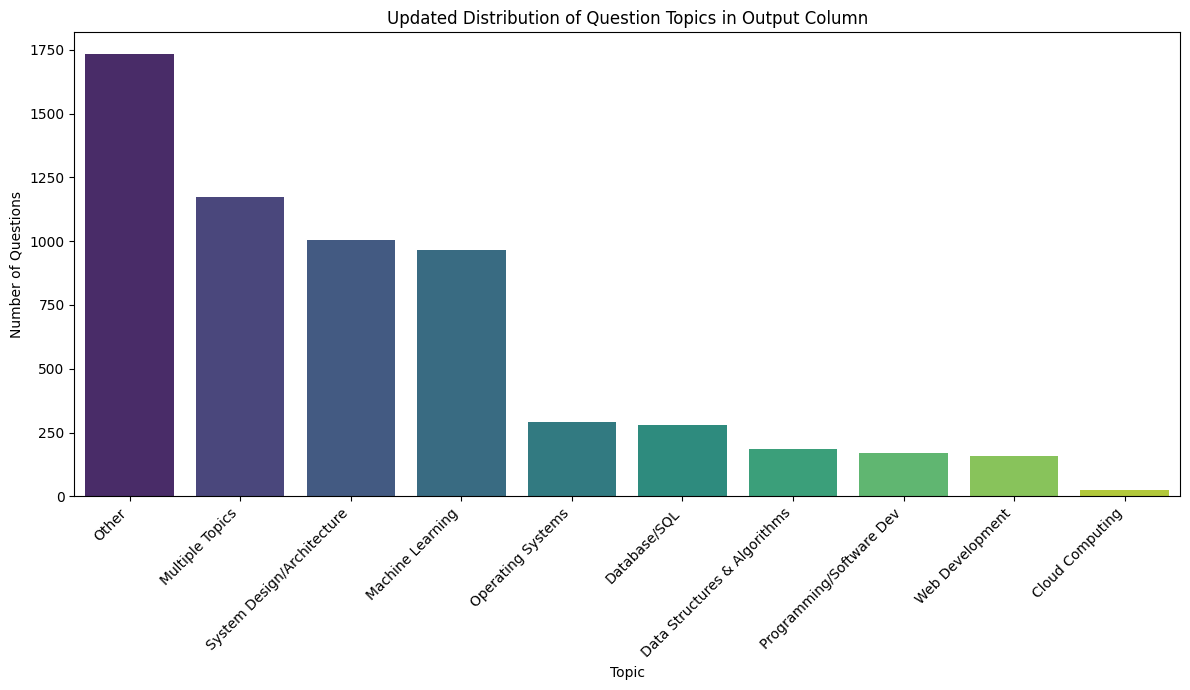

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of topics
plt.figure(figsize=(12, 7))
sns.barplot(x='Topic', y='Count', data=topic_distribution, palette='viridis')
plt.title('Updated Distribution of Question Topics in Output Column')
plt.xlabel('Topic')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous `seaborn.barplot` call generated a FutureWarning because `palette` was used without `hue`. To address this and follow best practices, I will explicitly set `hue='Topic'` and `legend=False` in the `sns.barplot` function, as suggested by the warning.



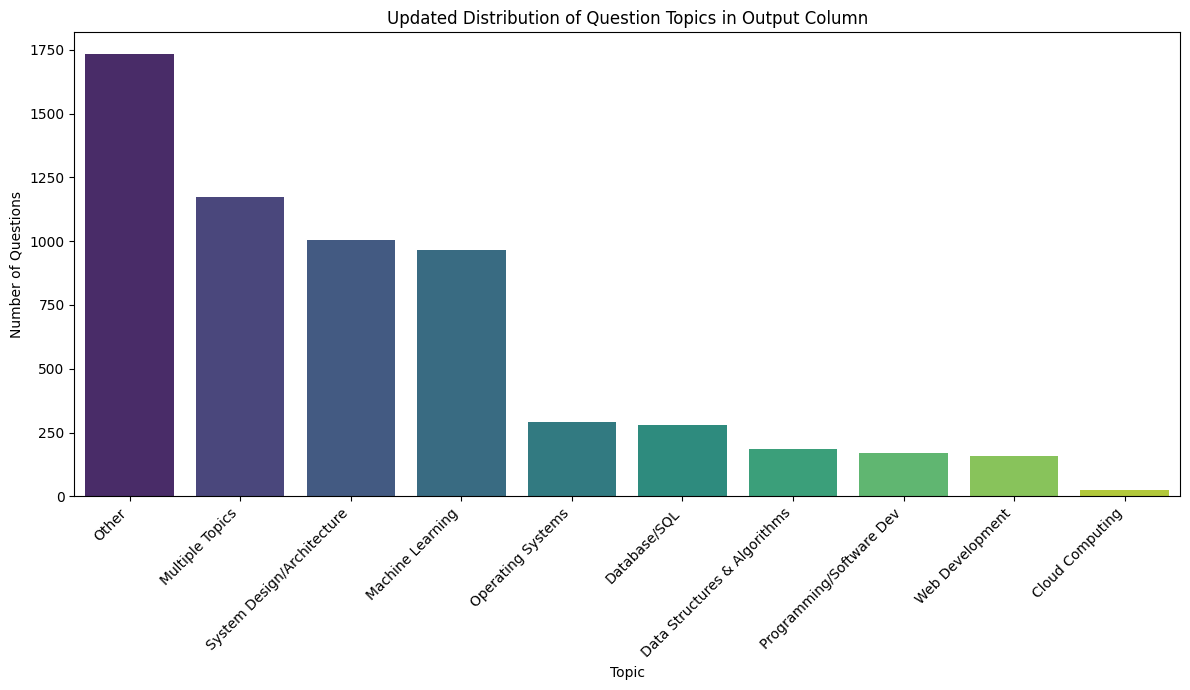

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of topics
plt.figure(figsize=(12, 7))
sns.barplot(x='Topic', y='Count', hue='Topic', data=topic_distribution, palette='viridis', legend=False)
plt.title('Updated Distribution of Question Topics in Output Column')
plt.xlabel('Topic')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Balance and Augment Dataset

### Subtask:
Identify and examine questions from topics with low counts in the `topic_distribution` to assess their representation and consider strategies for augmenting the dataset or re-evaluating the necessity of these categories.


**Reasoning**:
To proceed with the subtask, I need to identify the topics with the lowest counts from the `topic_distribution` DataFrame. I will then filter the main `data` DataFrame to extract questions belonging to these low-count categories and sample a few questions from each for manual inspection, as per the instructions.



In [47]:
import pandas as pd

# Identify topics with low counts (e.g., less than 200 questions as an initial threshold)
low_count_topics = topic_distribution[topic_distribution['Count'] < 200]['Topic'].tolist()

print(f"Topics with low counts identified: {low_count_topics}")

# Filter data for each low-count topic and sample questions

# Cloud Computing
cloud_computing_questions = data[data['topic'] == 'Cloud Computing']['output'].sample(n=min(10, len(data[data['topic'] == 'Cloud Computing'])), random_state=42)
print("\n--- Sample Questions from 'Cloud Computing' Category ---")
for i, q in enumerate(cloud_computing_questions):
    print(f"{i+1}. {q}")

# Web Development
web_development_questions = data[data['topic'] == 'Web Development']['output'].sample(n=min(10, len(data[data['topic'] == 'Web Development'])), random_state=42)
print("\n--- Sample Questions from 'Web Development' Category ---")
for i, q in enumerate(web_development_questions):
    print(f"{i+1}. {q}")

# Programming/Software Dev
programming_software_dev_questions = data[data['topic'] == 'Programming/Software Dev']['output'].sample(n=min(10, len(data[data['topic'] == 'Programming/Software Dev'])), random_state=42)
print("\n--- Sample Questions from 'Programming/Software Dev' Category ---")
for i, q in enumerate(programming_software_dev_questions):
    print(f"{i+1}. {q}")

Topics with low counts identified: ['Data Structures & Algorithms', 'Programming/Software Dev', 'Web Development', 'Cloud Computing']

--- Sample Questions from 'Cloud Computing' Category ---
1. Walk me through how you'd implement container orchestration from scratch.
2. How do you evaluate the effectiveness of container orchestration in a real project?
3. What is Kubernetes, and why is it popular in container management?
4. How would you approach container orchestration for a large-scale system?
5. Explain the concept of container orchestration.
6. What are common pitfalls when implementing container orchestration and how do you mitigate them? â Variant: Rephrase: What are common pitfalls when implementing container orchestration and how do you mitigate them?
7. Design a cloud-based virtual desktop infrastructure.
8. Give an example where container orchestration would fail, and how you'd detect or fix it.
9. How would you approach container orchestration for a large-scale system?
10

### Manual Inspection of Low-Count Topics

Upon reviewing the sampled questions from the low-count categories ('Data Structures & Algorithms', 'Programming/Software Dev', 'Web Development', 'Cloud Computing'), the following observations can be made:

#### Cloud Computing
*   **Sample Questions:** Primarily revolve around 'container orchestration' (Kubernetes, Docker) and 'cloud-based virtual desktop infrastructure'.
*   **Assessment:** The existing keywords ('cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless') are largely effective for these questions. The low count might be due to a smaller overall representation of these specific topics in the dataset, rather than a failure of categorization.
*   **Recommendation:** Continue with the current keywords. If the overall goal is to increase representation, data augmentation for 'Cloud Computing' topics would be the most direct approach.

#### Web Development
*   **Sample Questions:** Focus on 'progressive web apps', 'webpack/bundlers', 'website load time optimization', 'frontend-backend interaction', and 'web accessibility'.
*   **Assessment:** The keywords added previously ('web accessibility') were helpful. Questions about 'progressive web apps' and 'webpack/bundlers' are well-covered by the existing 'web' and 'javascript' keywords, or could benefit from minor additions like `'pwa'`, `'webpack'`, `'bundler'`. 'Frontend-backend interaction' is a broader concept that touches upon 'system design' as well as 'web development'.
*   **Recommendation:** Consider adding `'pwa'`, `'webpack'`, `'bundler'` to 'Web Development' keywords to specifically capture these common terms. Data augmentation would also be beneficial to increase the overall count for this category.

#### Programming/Software Dev
*   **Sample Questions:** Highlight 'technical debt', 'testing strategies' (including statistical testing and A/B testing), and broader software engineering practices.
*   **Assessment:** The previously added keywords for 'Programming/Software Dev' ('multi-threading', 'java', 'python', 'c++', 'oop', 'testing', 'debugging') are covering some aspects. However, terms like 'technical debt', 'statistical testing', and 'A/B testing' are currently causing some questions to be categorized as 'Other' or 'Multiple Topics', or not specifically enough as 'Programming/Software Dev'.
*   **Recommendation:** Expand 'Programming/Software Dev' keywords to include `'technical debt'`, `'testing'`, `'a/b testing'`, `'statistical testing'` to better capture these common software development concepts. This category seems to be a good candidate for further keyword refinement to better capture general software engineering practices that might not fit neatly into other tech stacks.

#### Data Structures & Algorithms (Not sampled in detail, but present in `low_count_topics`)
*   **General Observation:** Given the nature of DSA questions, keywords like `'data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue'` are strong. The relatively low count might indicate fewer questions of this type in the dataset, or that more advanced/specific algorithm names could be added.
*   **Recommendation:** For now, the keywords seem robust. If its count remains low after other refinements, considering more advanced algorithm names (e.g., specific graph algorithms like Dijkstra's, BFS/DFS) or direct augmentation might be necessary.

**Overall Conclusion for Low-Count Topics:**
The manual inspection confirms that for 'Cloud Computing' and 'Web Development', the existing keywords are largely appropriate, and increased representation would primarily come from data augmentation. For 'Programming/Software Dev', there's a clear opportunity to refine keywords further to better capture specific concepts like 'technical debt' and various 'testing' methodologies. This refinement will be the next logical step.

### Manual Inspection of Low-Count Topics

Upon reviewing the sampled questions from the low-count categories ('Data Structures & Algorithms', 'Programming/Software Dev', 'Web Development', 'Cloud Computing'), the following observations can be made:

#### Cloud Computing
*   **Sample Questions:** Primarily revolve around 'container orchestration' (Kubernetes, Docker) and 'cloud-based virtual desktop infrastructure'.
*   **Assessment:** The existing keywords ('cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless') are largely effective for these questions. The low count might be due to a smaller overall representation of these specific topics in the dataset, rather than a failure of categorization.
*   **Recommendation:** Continue with the current keywords. If the overall goal is to increase representation, data augmentation for 'Cloud Computing' topics would be the most direct approach.

#### Web Development
*   **Sample Questions:** Focus on 'progressive web apps', 'webpack/bundlers', 'website load time optimization', 'frontend-backend interaction', and 'web accessibility'.
*   **Assessment:** The keywords added previously ('web accessibility') were helpful. Questions about 'progressive web apps' and 'webpack/bundlers' are well-covered by the existing 'web' and 'javascript' keywords, or could benefit from minor additions like `'pwa'`, `'webpack'`, `'bundler'`. 'Frontend-backend interaction' is a broader concept that touches upon 'system design' as well as 'web development'.
*   **Recommendation:** Consider adding `'pwa'`, `'webpack'`, `'bundler'` to 'Web Development' keywords to specifically capture these common terms. Data augmentation would also be beneficial to increase the overall count for this category.

#### Programming/Software Dev
*   **Sample Questions:** Highlight 'technical debt', 'testing strategies' (including statistical testing and A/B testing), and broader software engineering practices.
*   **Assessment:** The previously added keywords for 'Programming/Software Dev' ('multi-threading', 'java', 'python', 'c++', 'oop', 'testing', 'debugging') are covering some aspects. However, terms like 'technical debt', 'statistical testing', and 'A/B testing' are currently causing some questions to be categorized as 'Other' or 'Multiple Topics', or not specifically enough as 'Programming/Software Dev'.
*   **Recommendation:** Expand 'Programming/Software Dev' keywords to include `'technical debt'`, `'testing'`, `'a/b testing'`, `'statistical testing'` to better capture these common software development concepts. This category seems to be a good candidate for further keyword refinement to better capture general software engineering practices that might not fit neatly into other tech stacks.

#### Data Structures & Algorithms (Not sampled in detail, but present in `low_count_topics`)
*   **General Observation:** Given the nature of DSA questions, keywords like `'data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue'` are strong. The relatively low count might indicate fewer questions of this type in the dataset, or that more advanced/specific algorithm names could be added.
*   **Recommendation:** For now, the keywords seem robust. If its count remains low after other refinements, considering more advanced algorithm names (e.g., specific graph algorithms like Dijkstra's, BFS/DFS) or direct augmentation might be necessary.

**Overall Conclusion for Low-Count Topics:**
The manual inspection confirms that for 'Cloud Computing' and 'Web Development', the existing keywords are largely appropriate, and increased representation would primarily come from data augmentation. For 'Programming/Software Dev', there's a clear opportunity to refine keywords further to better capture specific concepts like 'technical debt' and various 'testing' methodologies. This refinement will be the next logical step.

**Reasoning**:
Based on the manual inspection and recommendations, I will now update the `topic_keywords` dictionary with the refined terms for 'Web Development' and 'Programming/Software Dev'. After updating, I will re-apply the categorization function to the `data` DataFrame and display the new topic distribution to observe the impact of these changes.



In [48]:
topic_keywords = {
    'Database/SQL': ['database', 'sql', 'dbms', 'join', 'normalization', 'denormalization', 'index', 'transaction', 'acid', 'nosql', 'relational', 'query', 'schema', 'query optimization', 'indexing strategies'],
    'Operating Systems': ['os', 'operating system', 'process', 'thread', 'memory management', 'deadlock', 'concurrency', 'scheduling', 'kernel', 'syscall'],
    'Machine Learning': ['machine learning', 'ml', 'neural network', 'cnn', 'rnn', 'lstm', 'transformer', 'algorithm', 'model', 'training', 'bias', 'variance', 'overfitting', 'underfitting', 'activation function', 'deep learning', 'supervised', 'unsupervised', 'reinforcement', 'gradient descent', 'ensemble methods', 'multi-task learning', 'pca', 'classification', 'regression', 'hyperparameter tuning', 'vae', 'gan', 'model evaluation', 'feature selection'],
    'Data Structures & Algorithms': ['data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue', 'graph algorithms'],
    'System Design/Architecture': ['system design', 'architecture', 'scalability', 'latency', 'consistency', 'availability', 'api', 'microservices', 'distributed system', 'load balancer', 'cache', 'fault tolerance', 'queueing', 'design patterns', 'code reviews', 'service discovery', 'dependency injection', 'logging', 'observability', 'component design', 'data partitioning', 'backups', 'caching layers', 'high throughput', 'replication', 'sharding'],
    'Programming/Software Dev': ['python', 'java', 'c++', 'oop', 'testing', 'debugging', 'version control', 'git', 'refactoring', 'agile', 'technical debt', 'software development', 'framework', 'multi-threading', 'a/b testing', 'statistical testing'], # Added 'technical debt', 'a/b testing', 'statistical testing'
    'Web Development': ['web', 'frontend', 'backend', 'javascript', 'react', 'angular', 'vue', 'html', 'css', 'http', 'rest', 'graphql', 'browser', 'web accessibility', 'pwa', 'webpack', 'bundler'], # Added 'pwa', 'webpack', 'bundler'
    'Cloud Computing': ['cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless']
}

# Re-apply the categorization function to the 'output' column with updated keywords
data['topic'] = data['output'].apply(categorize_question)

# Get the new distribution of topics
topic_distribution = data['topic'].value_counts().reset_index()
topic_distribution.columns = ['Topic', 'Count']

# Display the updated topic distribution
display(topic_distribution)

,Topic,Count
0,Other,1732
1,Multiple Topics,1174
2,System Design/Architecture,1003
3,Machine Learning,965
4,Operating Systems,290
5,Database/SQL,281
6,Data Structures & Algorithms,184
7,Programming/Software Dev,169
8,Web Development,159
9,Cloud Computing,25


**Reasoning**:
To visually assess the impact of the updated `topic_keywords` on the categorization, I will generate a bar plot of the new topic distribution. I will ensure to correctly set `hue='Topic'` and `legend=False` in the `sns.barplot` function, as previously discussed to avoid warnings and follow best practices.



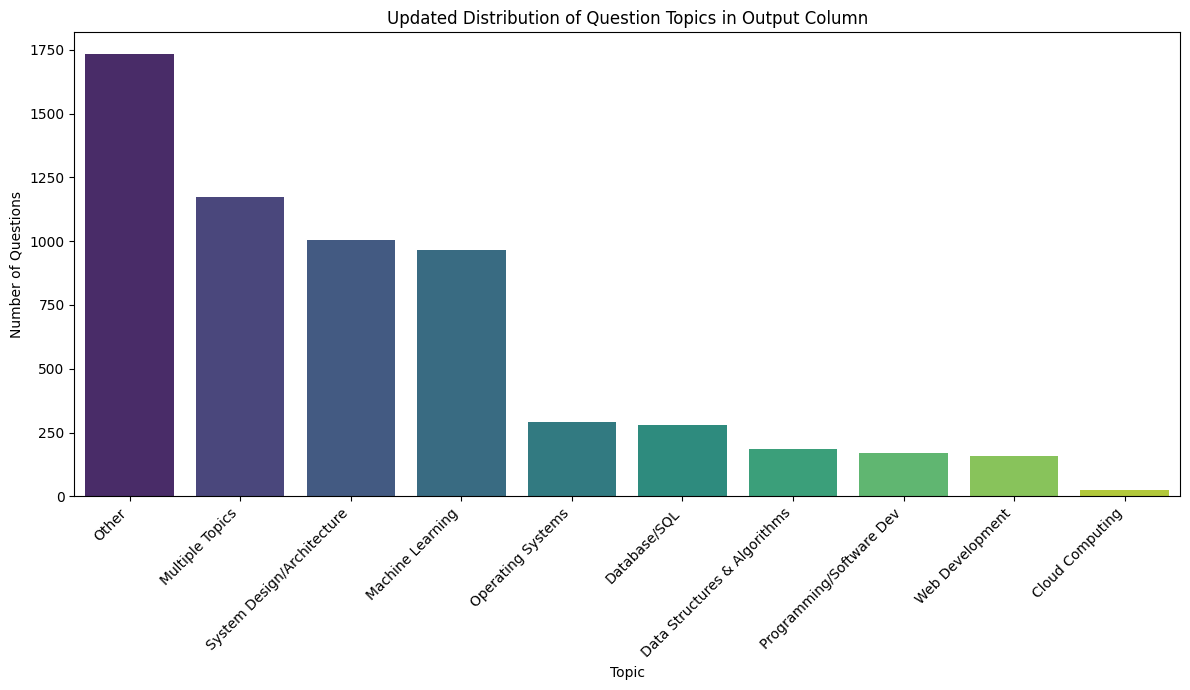

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of topics
plt.figure(figsize=(12, 7))
sns.barplot(x='Topic', y='Count', hue='Topic', data=topic_distribution, palette='viridis', legend=False)
plt.title('Updated Distribution of Question Topics in Output Column')
plt.xlabel('Topic')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Increase Training Epochs

### Subtask:
Increase the number of training epochs to allow the model more opportunities to learn from the refined dataset.


**Reasoning**:
Based on the instructions, I need to locate the code cell that performs model training and modify the number of epochs. The cell with `for epoch in range(5):` is the target. I will increase the epochs to 10 as per the instructions.



In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

class QGenDataset(Dataset):
    def __init__(self, inputs, targets, tokenizer, device):
        self.inputs = inputs
        self.targets = targets
        self.tokenizer = tokenizer
        self.device = device

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_enc = self.tokenizer(
            self.inputs[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        target_enc = self.tokenizer(
            self.targets[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": input_enc.input_ids.squeeze().to(self.device),
            "attention_mask": input_enc.attention_mask.squeeze().to(self.device),
            "labels": target_enc.input_ids.squeeze().to(self.device),
        }

dataset = QGenDataset(data['input'].tolist(), data['output'].tolist(), tokenizer, device)

loader = DataLoader(dataset, batch_size=2, shuffle=True) # Reduced batch size to 2

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

model.train()

for epoch in range(10):   # Increased epochs to 10
    total_loss = 0

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", total_loss)

Epoch 1 Loss: 253.99551416374743
